# Predicting Biophysical Protein Stability

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/splicing_matrix.csv")

# 1. Feature Engineering
df["delta_IF"] = df["IF_DMD"] - df["IF_WT"]
df["log2_FC"] = np.log2(df["fold_change"])

# 2. Filter out low-expression noise BEFORE identifying switches
expression_cutoff = 1.0  # At least 1 TPM in either WT or DMD
significant_switch_cutoff = 0.3

expressed_mask = (df["mean_TPM_WT"] >= expression_cutoff) | (
    df["mean_TPM_DMD"] >= expression_cutoff
)
switch_mask = df["delta_IF"].abs() > significant_switch_cutoff

# Filtered transcript subset
df_switches = df[expressed_mask & switch_mask]
switch_tx_ids = df_switches["Transcript_ID"].dropna().unique().tolist()

print(
    f"[STATUS] Total raw switches: {len(df[switch_mask])}"
)  # Was 3,525 (includes noise)
print(
    f"[STATUS] Genuine expressed switches (TPM >= 1): {len(switch_tx_ids)}"
)  # Drastically reduced

[STATUS] Total raw switches: 3525
[STATUS] Genuine expressed switches (TPM >= 1): 1427


[STATUS] Indexing cDNA FASTA...
[STATUS] Successfully calculated stability metrics for 1171 transcripts.
[STATUS] Saved integrated matrix to CSV.


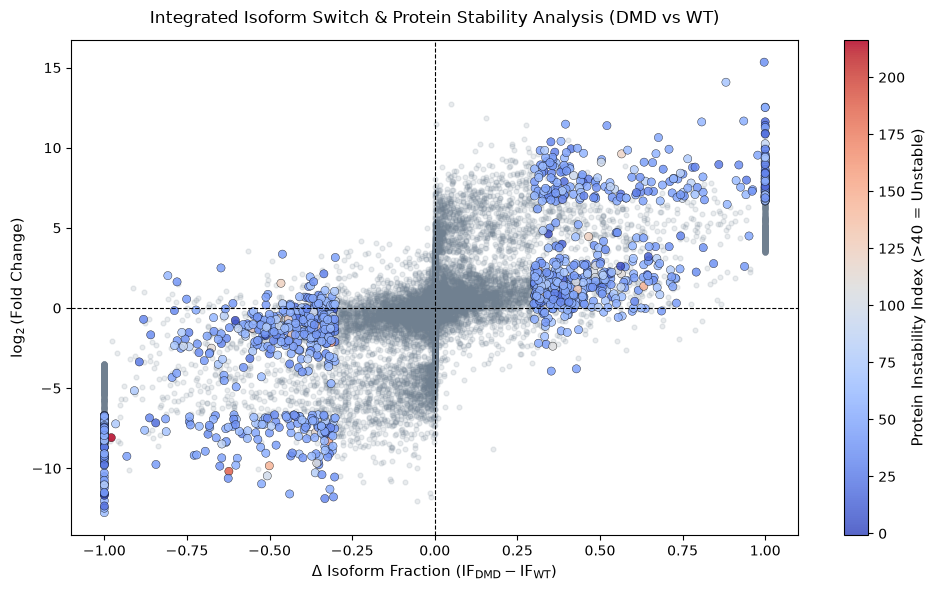

In [8]:
import gzip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# 1. Feature Engineering
df["delta_IF"] = df["IF_DMD"] - df["IF_WT"]
df["log2_FC"] = np.log2(df["fold_change"])

# Filter for expressed switches
expressed = (df["mean_TPM_WT"] >= 1.0) | (df["mean_TPM_DMD"] >= 1.0)
df_switches = df[expressed & (df["delta_IF"].abs() > 0.3)]
switch_tx_ids = df_switches["Transcript_ID"].dropna().unique().tolist()

# 2. Local FASTA Processing with Clean Codon Trimming
fasta_path = "../data/reference/Sus_scrofa.Sscrofa11.1.cdna.all.fa.gz"
fasta_dict = {}

print("[STATUS] Indexing cDNA FASTA...")
with gzip.open(fasta_path, "rt") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        tx_id = record.id.split(".")[0]
        fasta_dict[tx_id] = str(record.seq)

protein_results = []
for tid in switch_tx_ids:
    if tid in fasta_dict:
        seq_str = fasta_dict[tid]
        start_idx = seq_str.find("ATG")

        if start_idx != -1:
            cds_candidate = seq_str[start_idx:]

            # Trim trailing nucleotides to force exact multiples of 3 (fixes Biopython warning)
            trim_len = len(cds_candidate) - (len(cds_candidate) % 3)
            cds_candidate = cds_candidate[:trim_len]

            prot_seq = str(Seq(cds_candidate).translate(to_stop=True))

            if len(prot_seq) > 10:
                analysis = ProteinAnalysis(prot_seq)
                instability = analysis.instability_index()
                protein_results.append(
                    {
                        "Transcript_ID": tid,
                        "Length_AA": len(prot_seq),
                        "Instability_Index": round(instability, 2),
                        "Stability_Class": (
                            "Unstable" if instability > 40 else "Stable"
                        ),
                        "GRAVY": round(analysis.gravy(), 2),
                        "pI": round(analysis.isoelectric_point(), 2),
                    }
                )

df_protein = pd.DataFrame(protein_results)
print(
    f"[STATUS] Successfully calculated stability metrics for {len(df_protein)} transcripts."
)

# 3. Merge Datasets
df_integrated = pd.merge(df, df_protein, on="Transcript_ID", how="left")

# Save processed matrix for downstream statistical testing
df_integrated.to_csv(
    "../data/processed/splicing_protein_integrated.csv", index=False
)
print("[STATUS] Saved integrated matrix to CSV.")

# 4. Generate Integrated Plot
plt.figure(figsize=(10, 6))

# Background: Non-significant or unmapped transcripts
plt.scatter(
    df_integrated[df_integrated["Instability_Index"].isna()]["delta_IF"],
    df_integrated[df_integrated["Instability_Index"].isna()]["log2_FC"],
    alpha=0.15,
    s=12,
    color="slategray",
    label="Minor / Unmapped",
)

# Active Isoform Switches mapped to Protein Instability
switches = df_integrated.dropna(subset=["Instability_Index"])
scatter = plt.scatter(
    switches["delta_IF"],
    switches["log2_FC"],
    c=switches["Instability_Index"],
    cmap="coolwarm",
    s=35,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.85,
)

cbar = plt.colorbar(scatter)
cbar.set_label("Protein Instability Index (>40 = Unstable)", fontsize=11)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)

plt.title(
    "Integrated Isoform Switch & Protein Stability Analysis (DMD vs WT)",
    fontsize=12,
    pad=12,
)
plt.xlabel(
    r"$\Delta$ Isoform Fraction ($\text{IF}_{\text{DMD}} - \text{IF}_{\text{WT}}$)",
    fontsize=11,
)
plt.ylabel(r"$\log_2(\text{Fold Change})$", fontsize=11)
plt.tight_layout()
plt.show()